# Prescient Coding Challenge 2026 — `solution.py` (notebook version)

Notebook split of the submitted `generate_weights()` pipeline: raw features **and** a small NN's hidden-layer features both feed an Extra Trees regressor, which predicts each asset's forward return. That prediction becomes the tilt signal that `make_legal()` and the daily `trade_speed` step-through turn into a legal, cost-aware portfolio.

**This notebook is for exploration only.** The actual submission is `solution.py` — only that file may be changed, and only it is diffed. Use this notebook to poke at feature engineering, watch a single refit happen, and plot the resulting signal; don't submit the notebook itself.

## Imports

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

## Parameters and rules

Every tuneable number lives in `PARAMS` (parameter count is scored, so fewer is better). The constraint constants below are restated locally so this file — and this notebook — reads on its own.

In [2]:
PARAMS = {
    "tilt_size":       0.06,   # how far a 1-sigma signal moves a weight
    "trade_speed":     0.10,   # fraction of the gap to yesterday closed per day
    "forward_horizon": 5,      # days-ahead return the model is trained to predict
    "min_train_rows":  500,    # trading days of history required before trusting the model
    "refit_every":     21,     # trading days between refits (~monthly)
    "hidden_units":    16,     # width of the NN feature-extractor's hidden layer
    "et_n_estimators": 150,    # trees in the Extra Trees ensemble
    "et_max_depth":    6,      # cap tree depth -- fights overfitting on ~20yrs of data
    "train_lookback":  2000,   # trading days (~8yrs) of history used to fit each refit
    "random_seed":     7,      # seeds every source of randomness -> deterministic
}

# The rules, restated locally so this file reads on its own.
ACTIVE_BAND = 0.10       # per asset, distance from benchmark
ACTIVE_BUDGET = 0.40     # total, summed over assets
EQUITY = ["SA_EQUITY", "GLOBAL_EQUITY"]
EQUITY_CAP = 0.75        # total equity, whatever the bands allow
GOLD_CAP = 0.10

## Feature engineering constants

In [3]:
RET_LAGS = (1, 5, 10, 20, 60)          # trailing return windows, in trading days
VOL_WINDOWS = (20, 60)                 # trailing realised-vol windows
MACRO_COLS = [
    "usdzar", "dxy", "vix", "brent", "us_2y", "us_10y",
    "sa_10y", "jibar_3m", "sa_repo", "em_equity",
]

# Fitted model persists here across daily calls within one process, so we
# refit on a schedule instead of on every single trading day.
_CACHE: dict = {"model": None, "trained_at_n": None}

## Raw per-asset and macro features

`_asset_features` computes trailing returns and realised vol from the full history (used only at refit time). `_macro_features` deliberately does **not** z-score — that's left to the final `x_mean`/`x_std` standardisation fit once per refit, so this function doesn't need to recompute a rolling mean/std over ~20 years on every call.

In [4]:
def _asset_features(returns_col: pd.Series, prices_col: pd.Series) -> pd.DataFrame:
    """Raw per-asset features: trailing returns and realised vol."""
    feats = {}
    for lag in RET_LAGS:
        feats[f"ret_{lag}d"] = prices_col.pct_change(lag)
    for w in VOL_WINDOWS:
        feats[f"vol_{w}d"] = returns_col.rolling(w).std() * np.sqrt(252)
    return pd.DataFrame(feats, index=returns_col.index)


def _macro_features(macro: pd.DataFrame) -> pd.DataFrame:
    """Macro levels (raw) plus two curve spreads.

    No z-scoring here on purpose: the final pipeline standardises the whole
    feature vector (`x_mean`/`x_std`, fit once at refit time) anyway, and
    z-scoring macro afresh from full history would mean recomputing a
    rolling mean/std over ~20 years every single day just to read off one
    row -- exactly the daily-cost mistake `_latest_asset_row` below is
    written to avoid.
    """
    cols = [c for c in MACRO_COLS if c in macro.columns]
    feats = macro[cols].copy()
    if "us_10y" in macro.columns and "us_2y" in macro.columns:
        feats["us_curve"] = macro["us_10y"] - macro["us_2y"]
    if "sa_10y" in macro.columns and "jibar_3m" in macro.columns:
        feats["sa_curve"] = macro["sa_10y"] - macro["jibar_3m"]
    return feats

## Training panel (built only at refit time)

Stacks all six assets into one panel — rows are `(date, asset)` — with lag/vol features, shared macro features, a one-hot asset id, and the forward-return training target. Pooling assets multiplies the effective training sample six-fold, which matters with a small NN and ~20 years of daily data.

In [5]:
def _build_panel(hist, forward_horizon: int) -> pd.DataFrame:
    """Stack all six assets into one training panel (rows = date x asset).

    Only used at refit time (every `refit_every` days), never on every
    daily call -- it walks the full history with vectorised pandas ops,
    which is fine occasionally but far too slow to redo every single day.

    Each row carries that asset's lag/vol features, the day's shared macro
    features, a one-hot asset id (so one pooled model can still tell assets
    apart), and the forward return used only as the training target.
    Pooling assets into one panel multiplies the effective training sample
    six-fold, which matters a lot with a small NN and only ~20 years of data.
    """
    macro_feats = _macro_features(hist.macro)
    frames = []
    for asset in hist.assets:
        panel = _asset_features(hist.returns[asset], hist.prices[asset])
        panel = panel.join(macro_feats, how="left")
        panel["fwd_return"] = (
            hist.prices[asset].pct_change(forward_horizon).shift(-forward_horizon)
        )
        for a2 in hist.assets:
            panel[f"is_{a2}"] = 1.0 if a2 == asset else 0.0
        panel["_asset"] = asset
        frames.append(panel)
    return pd.concat(frames, axis=0)

## Today's features (built on every daily call)

The cheap path: reads only the tail of the history needed for the longest lookback (60 days), so this stays fast no matter how many years of data have accumulated by the time you're deep into a window. This is what fixed a 93-second-per-window bug from an earlier version that rebuilt the *entire* historical panel on every single day.

In [6]:
def _latest_asset_row(hist, asset: str) -> dict:
    """Today's raw features for one asset, computed off only the tail of the
    history -- O(lookback), not O(full history). This is what runs on every
    single daily call, so it has to stay cheap regardless of how many years
    of data have piled up by the time we're deep into the 2025 or 2026
    windows.
    """
    max_lookback = max(max(RET_LAGS), max(VOL_WINDOWS)) + 1
    prices_tail = hist.prices[asset].tail(max_lookback)
    returns_tail = hist.returns[asset].tail(max_lookback)

    row = {}
    for lag in RET_LAGS:
        if len(prices_tail) > lag:
            row[f"ret_{lag}d"] = prices_tail.iloc[-1] / prices_tail.iloc[-1 - lag] - 1.0
        else:
            row[f"ret_{lag}d"] = np.nan
    for w in VOL_WINDOWS:
        row[f"vol_{w}d"] = returns_tail.tail(w).std() * np.sqrt(252)
    return row


def _latest_features(hist) -> pd.DataFrame:
    """Today's feature row for every asset, in the same columns/order that
    `_build_panel` produces -- but built from tail slices only, so it is
    cheap enough to call once per day.
    """
    macro_row = hist.macro.iloc[-1]
    macro_cols = [c for c in MACRO_COLS if c in hist.macro.columns]
    macro_feats = {c: macro_row[c] for c in macro_cols}
    if "us_10y" in macro_row and "us_2y" in macro_row:
        macro_feats["us_curve"] = macro_row["us_10y"] - macro_row["us_2y"]
    if "sa_10y" in macro_row and "jibar_3m" in macro_row:
        macro_feats["sa_curve"] = macro_row["sa_10y"] - macro_row["jibar_3m"]

    rows = {}
    for asset in hist.assets:
        row = _latest_asset_row(hist, asset)
        row.update(macro_feats)
        for a2 in hist.assets:
            row[f"is_{a2}"] = 1.0 if a2 == asset else 0.0
        rows[asset] = row
    return pd.DataFrame(rows).T.reindex(hist.assets)

## NN hidden-layer extraction

The "NN-learned features" half of the pipeline: the hidden-layer activations of the fitted MLP become extra input columns for Extra Trees, on top of the raw features.

In [7]:
def _mlp_hidden(nn: MLPRegressor, X: np.ndarray) -> np.ndarray:
    """Hidden-layer activations of the fitted 1-hidden-layer, ReLU MLP.

    This is the "NN learned features" half of the pipeline: rather than only
    handing Extra Trees the raw inputs, we also hand it the nonlinear
    combinations of those inputs that the NN learned while training toward
    the same forward-return target.
    """
    z = X @ nn.coefs_[0] + nn.intercepts_[0]
    return np.maximum(z, 0.0)

## Fit the NN + Extra Trees pipeline

Runs only at refit time (every `refit_every` trading days), on a rolling `train_lookback` window rather than full history — cheaper, and keeps the model reading current regimes instead of diluting them against, e.g., 2004-08 pre-crisis data.

In [8]:
def _fit_pipeline(hist, params: dict):
    """Fit the NN feature-extractor + Extra Trees pipeline on all history
    strictly before hist.date. Returns None if there isn't enough clean data
    yet (only possible right at the start of the full history).
    """
    seed = int(params["random_seed"])
    np.random.seed(seed)

    panel = _build_panel(hist, int(params["forward_horizon"]))
    feature_cols = [c for c in panel.columns if c not in ("fwd_return", "_asset")]

    # Fit on a rolling lookback rather than the full ~20-year history: it's
    # cheaper to refit, and it keeps the model reading current regimes
    # rather than diluting them against, e.g., 2004-08 pre-crisis data.
    lookback = int(params["train_lookback"])
    cutoff = hist.returns.index[-lookback] if len(hist.returns) > lookback else hist.returns.index[0]
    panel = panel.loc[panel.index >= cutoff]

    train = panel.dropna(subset=feature_cols + ["fwd_return"])
    if len(train) < 200:
        return None

    X = train[feature_cols].to_numpy(dtype=float)
    y = train["fwd_return"].to_numpy(dtype=float)

    x_mean, x_std = X.mean(axis=0), X.std(axis=0)
    x_std[x_std == 0.0] = 1.0
    Xs = (X - x_mean) / x_std

    nn = MLPRegressor(
        hidden_layer_sizes=(int(params["hidden_units"]),),
        activation="relu",
        solver="lbfgs",          # full-batch, deterministic given random_state
        max_iter=300,
        random_state=seed,
    )
    nn.fit(Xs, y)
    hidden = _mlp_hidden(nn, Xs)

    et = ExtraTreesRegressor(
        n_estimators=int(params["et_n_estimators"]),
        max_depth=int(params["et_max_depth"]),
        random_state=seed,
        n_jobs=-1,                # parallel is fine: fixed random_state gives
                                  # bit-identical trees regardless of n_jobs
    )
    et.fit(np.hstack([Xs, hidden]), y)

    return {
        "nn": nn, "et": et,
        "x_mean": x_mean, "x_std": x_std,
        "feature_cols": feature_cols,
    }

## Refit scheduling and the module-level cache

Refitting on every one of ~250 daily calls per window would blow the 10-minute budget, so the fitted model is cached and refit only periodically. The one correctness subtlety: if the harness ever hands this function *less* history than the cached model was trained on, that means an earlier window is running after a later one — the cache would otherwise leak future information into the past, so a shrink forces an immediate refit rather than reusing the stale model.

In [9]:
def _maybe_refit(hist, params: dict):
    """Return a cached, up-to-date model; refit only when the schedule says to.

    The one subtlety: `validate.py` scores several windows (2015, 2016, 2020,
    2022, 2025, ...) and there is no guarantee they run in chronological
    order within the process. If the amount of history we've been handed
    ever *shrinks* relative to what the cached model was trained on, that
    means we've been handed an earlier window after a later one -- the
    cached model would effectively be trained on the future relative to
    this window, which is exactly the look-ahead bias the harness is built
    to prevent. So a shrink forces an immediate refit, not just a stale one.
    """
    n_rows = len(hist.returns)
    if n_rows < int(params["min_train_rows"]):
        return None

    trained_at_n = _CACHE["trained_at_n"]
    needs_refit = (
        _CACHE["model"] is None
        or trained_at_n is None
        or n_rows < trained_at_n
        or n_rows - trained_at_n >= int(params["refit_every"])
    )
    if needs_refit:
        model = _fit_pipeline(hist, params)
        if model is not None:
            _CACHE["model"] = model
            _CACHE["trained_at_n"] = n_rows

    return _CACHE["model"]

## The signal

Predicts each asset's forward return with the cached pipeline, then z-scores across the six assets so the signal's scale is stable through time. Falls back to a flat zero signal (sit on the benchmark) whenever there isn't yet enough history to trust a fit.

In [10]:
def build_signal(hist, params) -> pd.Series:
    """Score per asset. Positive means overweight, negative means underweight.

    Predicts each asset's forward return with the cached NN+Extra-Trees
    pipeline, then z-scores across the six assets so the signal scale is
    stable through time (matching the shipped placeholder's convention).
    Falls back to a flat zero signal (sit on the benchmark) whenever there
    isn't yet enough history to trust a fitted model.
    """
    model = _maybe_refit(hist, params)
    if model is None:
        return pd.Series(0.0, index=hist.assets)

    latest = _latest_features(hist)[model["feature_cols"]]
    if latest.isna().any().any():
        return pd.Series(0.0, index=hist.assets)

    Xs = (latest.to_numpy(dtype=float) - model["x_mean"]) / model["x_std"]
    hidden = _mlp_hidden(model["nn"], Xs)
    pred = model["et"].predict(np.hstack([Xs, hidden]))

    score = pd.Series(pred, index=hist.assets)
    if score.std() > 0:
        score = (score - score.mean()) / score.std()
    return score

## `make_legal` — constraint enforcement (unchanged from the shipped scaffold)

In [11]:
def make_legal(weights: pd.Series, hist) -> pd.Series:
    """Force `weights` to satisfy every rule. You can leave this alone.

    Everything happens in active space -- how far each asset sits from its
    benchmark weight -- because that is how the rules are written.

    The loop is there because the steps interfere: forcing the active weights
    to net to zero (so the portfolio sums to 1) can push an asset back outside
    its band. A few passes settles it. The budget scaling goes last and is safe
    there: shrinking every active weight toward zero cannot breach a band, a
    cap, or non-negativity.
    """
    bm = hist.benchmark
    active = weights.reindex(hist.assets).astype(float) - bm

    for _ in range(50):
        active = active.clip(lower=-ACTIVE_BAND, upper=ACTIVE_BAND)  # rule 2
        active = active.clip(lower=-bm)                              # keeps weights >= 0
        # rule 4: total equity cap. Trim the equity block back, sharing the
        # cut over whichever equity assets still have room to come down.
        eq_excess = (bm[EQUITY] + active[EQUITY]).sum() - EQUITY_CAP
        eq_full = eq_excess > -1e-12
        if eq_excess > 0:
            floor = np.maximum(-ACTIVE_BAND, -bm[EQUITY])
            down = (active[EQUITY] - floor).clip(lower=0)
            if down.sum() > 1e-15:
                active[EQUITY] = active[EQUITY] - eq_excess * down / down.sum()

        active["GOLD"] = min(active["GOLD"], GOLD_CAP - bm["GOLD"])  # rule 5

        excess = active.sum()          # must be zero for weights to sum to 1
        if abs(excess) < 1e-12:
            break
        # give the correction to the assets that have room to absorb it
        room = (ACTIVE_BAND - active) if excess < 0 else (active + bm).clip(lower=0)
        room = room.clip(lower=0)
        if excess < 0 and eq_full:
            room[EQUITY] = 0.0   # equity is at its cap -- top up elsewhere
        if room.sum() <= 1e-15:
            break
        active = active - excess * room / room.sum()

    total = active.abs().sum()                                       # rule 3
    if total > ACTIVE_BUDGET:
        active = active * (ACTIVE_BUDGET / total)

    return bm + active

## `generate_weights` — the function the harness actually calls

In [12]:
def generate_weights(hist, prev_weights, params):
    """Return the six portfolio weights to hold on hist.date."""
    bm = hist.benchmark

    # not enough history to trust the model yet: sit on the benchmark
    if len(hist.returns) < int(params["min_train_rows"]):
        return bm.to_dict()

    # 1. signal -> target weights around the benchmark
    signal = build_signal(hist, params)
    target = make_legal(bm + float(params["tilt_size"]) * signal, hist)

    # 2. trade gradually toward the target rather than jumping to it
    prev = prev_weights.reindex(hist.assets)
    w = prev + float(params["trade_speed"]) * (target - prev)

    return make_legal(w, hist).to_dict()

## Quick interactive check

Loads the real data via `harness.load_data()` and runs the practice window (2025), the same as `python harness.py`. Requires `harness.py` and the `data/` folder to be present alongside this notebook.

---> window            2025-01-02 to 2025-12-31  (250 days)
---> portfolio  (net)    26.75%  cumulative
---> benchmark           27.23%  cumulative
---> excess     (net)    -0.48%  cumulative
---> excess (scored)    -0.151   bps/day
---> information ratio   -0.29
---> active weight       18.77% average, 25.91% peak (budget 40%)
---> cost drag            0.69%   avg daily turnover 0.71%
---> max drawdown        -7.13%
run time 0:01:14.831378


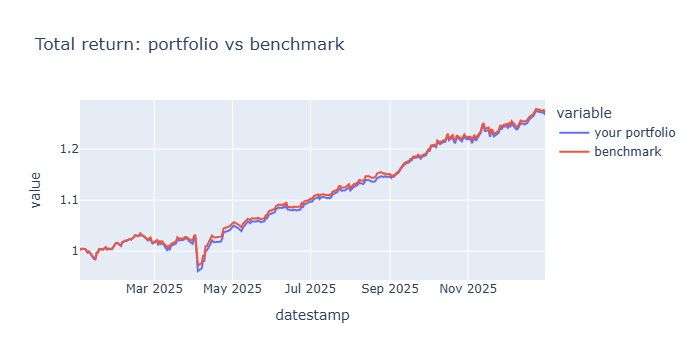

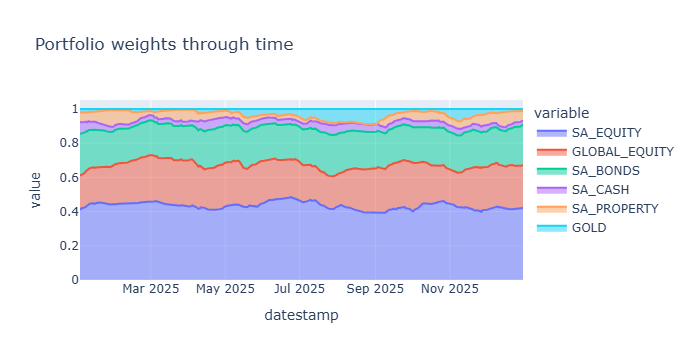

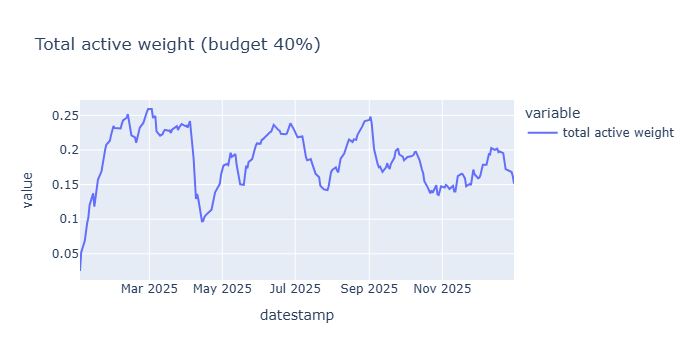

In [14]:
import datetime as dt
import harness

t0 = dt.datetime.now()
result = harness.run_backtest(
    generate_weights, PARAMS,
    start=harness.PRACTICE_WINDOW[0], end=harness.PRACTICE_WINDOW[1],
)
print(f"run time {dt.datetime.now() - t0}")
harness.plot_result(result)

## Before you submit

This notebook is scratch space. Copy any changes back into `solution.py` — that's the only file that gets diffed and graded — then run:

```bash
python harness.py
python validate.py
```

`validate.py` must say **"All windows passed"** before you submit.